# Weather-GRU + VI Fusion for Tar-Spot Severity (PPAC-B3, 2021)

Ablation: does a **GRU weather branch** improve a pure **VI-statistics -> SEVERITY**
regression?

- **VI branch**: 48 VI stats + `CANOPY_COVER` (49 features) per plot/date.
- **Weather branch**: daily weather (season-start -> flight date, cumulative) encoded by a
  GRU into a hidden state; weather is field-level so the hidden state is shared by all plots
  on a given flight date.
- **Baseline** = VI-only MLP; **Treatment** = VI + weather-GRU. 5-fold `GroupKFold` by
  `POINT`, run for all 4 METHOD x SOIL combos. No autoregressive severity lags.

In [1]:
import random
from dataclasses import dataclass, field, replace

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.nn.utils.rnn import pack_padded_sequence
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

## Weather preprocessing

Hourly weather -> cleaned daily features -> cumulative per-flight-date sequences for the GRU.

In [2]:
RENAME_MAP = {
    " m³/m³ Water Content": "soil_water",
    " °C Soil Temperature": "soil_temp",
    " min Leaf Wetness": "leaf_wet_min",
    " W/m² Solar Radiation": "solar_rad",
    " mm Precipitation": "precip",
    "° Wind Direction": "wind_dir",
    " m/s Wind Speed": "wind_speed",
    " m/s Gust Speed": "gust_speed",
    " °C Air Temperature": "air_temp",
    " RH Relative Humidity": "rh",
    " kPa Atmospheric Pressure": "pressure",
    " mm/h Max Precip Rate": "max_precip_rate",
}
GDD_BASE_C = 10.0


def load_hourly(path):
    df = pd.read_excel(path, index_col=0)
    df.index = pd.to_datetime(df.index)
    df = df.sort_index()
    df = df[list(RENAME_MAP)].rename(columns=RENAME_MAP)
    df[["wind_dir", "wind_speed", "gust_speed"]] = (
        df[["wind_dir", "wind_speed", "gust_speed"]].interpolate("time")
    )
    return df


def _saturation_vp(temp_c):
    return 0.6108 * np.exp(17.27 * temp_c / (temp_c + 237.3))


def to_daily(hourly, derived=True):
    r = hourly.resample("D")
    theta = np.deg2rad(hourly["wind_dir"])
    out = pd.DataFrame(
        {
            "air_temp_mean": r["air_temp"].mean(),
            "air_temp_min": r["air_temp"].min(),
            "air_temp_max": r["air_temp"].max(),
            "soil_temp_mean": r["soil_temp"].mean(),
            "soil_temp_min": r["soil_temp"].min(),
            "soil_temp_max": r["soil_temp"].max(),
            "rh_mean": r["rh"].mean(),
            "rh_min": r["rh"].min(),
            "rh_max": r["rh"].max(),
            "solar_rad_sum": r["solar_rad"].sum(),
            "solar_rad_mean": r["solar_rad"].mean(),
            "precip_sum": r["precip"].sum(),
            "max_precip_rate": r["max_precip_rate"].max(),
            "wind_speed_mean": r["wind_speed"].mean(),
            "gust_speed_max": r["gust_speed"].max(),
            "wind_dir_sin": np.sin(theta).resample("D").mean(),
            "wind_dir_cos": np.cos(theta).resample("D").mean(),
            "soil_water_mean": r["soil_water"].mean(),
            "leaf_wet_min_sum": r["leaf_wet_min"].sum(),
        }
    )
    if derived:
        out["gdd"] = ((out["air_temp_max"] + out["air_temp_min"]) / 2 - GDD_BASE_C).clip(lower=0)
        out["vpd"] = _saturation_vp(out["air_temp_mean"]) * (1 - out["rh_mean"])
        out["leaf_wet_hours"] = out["leaf_wet_min_sum"] / 60.0
    return out


@dataclass
class WeatherSequences:
    dates: list
    feature_cols: list
    sequences: dict
    date_to_idx: dict = field(init=False)

    def __post_init__(self):
        self.date_to_idx = {d: i for i, d in enumerate(self.dates)}

    @property
    def lengths(self):
        return np.array([len(self.sequences[d]) for d in self.dates], dtype=np.int64)

    @property
    def n_features(self):
        return len(self.feature_cols)

    def padded_bank(self):
        max_len = int(self.lengths.max())
        bank = np.zeros((len(self.dates), max_len, self.n_features), dtype=np.float32)
        for i, d in enumerate(self.dates):
            seq = self.sequences[d]
            bank[i, : len(seq)] = seq
        return bank, self.lengths


def build_sequences(daily, flight_dates, feature_cols=None, season_start=None):
    if feature_cols is None:
        feature_cols = list(daily.columns)
    dates = sorted(pd.to_datetime(pd.Index(flight_dates)).normalize().unique())
    start = pd.Timestamp(season_start) if season_start is not None else daily.index.min()
    mat = daily[feature_cols]
    sequences = {d: mat.loc[start:d].to_numpy(dtype=np.float32) for d in dates}
    return WeatherSequences(dates=list(dates), feature_cols=feature_cols, sequences=sequences)

## Fusion model + training

`FusionRegressor` (GRU weather branch + VI-MLP head), the RF baseline, and the CV driver.

In [3]:
DEFAULT_COMBOS = [
    ("orthorectified", "YES"),
    ("orthorectified", "NO"),
    ("whole", "YES"),
    ("whole", "NO"),
]


@dataclass
class FusionConfig:
    hidden_dim: int = 32
    mlp_dims: tuple = (128, 64)
    dropout: float = 0.1
    lr: float = 1e-3
    weight_decay: float = 1e-4
    epochs: int = 150
    batch_size: int = 256
    max_grad_norm: float = 1.0
    use_weather: bool = True
    log_target: bool = False
    n_splits: int = 5
    seed: int = 42
    device: str = "cuda" if torch.cuda.is_available() else "cpu"


def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


def vi_feature_cols(df):
    stats = [c for c in df.columns if c.split("_")[-1] in ("MEAN", "STD", "MIN", "MAX")]
    return stats + (["CANOPY_COVER"] if "CANOPY_COVER" in df.columns else [])


def _mlp(in_dim, dims, out_dim, dropout):
    layers = []
    d = in_dim
    for h in dims:
        layers += [nn.Linear(d, h), nn.ReLU(), nn.Dropout(dropout)]
        d = h
    layers += [nn.Linear(d, out_dim)]
    return nn.Sequential(*layers)


class FusionRegressor(nn.Module):
    def __init__(self, vi_dim, weather_dim, cfg):
        super().__init__()
        self.use_weather = cfg.use_weather
        head_in = vi_dim
        if self.use_weather:
            self.gru = nn.GRU(weather_dim, cfg.hidden_dim, batch_first=True)
            head_in += cfg.hidden_dim
        self.head = _mlp(head_in, cfg.mlp_dims, 1, cfg.dropout)

    def encode_weather(self, bank, lengths):
        packed = pack_padded_sequence(bank, lengths.cpu(), batch_first=True, enforce_sorted=False)
        _, h_n = self.gru(packed)
        return h_n[-1]

    def forward(self, vi, date_idx, bank=None, lengths=None):
        if self.use_weather:
            h = self.encode_weather(bank, lengths)
            x = torch.cat([vi, h[date_idx]], dim=1)
        else:
            x = vi
        return self.head(x).squeeze(-1)


def run_combo(df_combo, daily, cfg, vi_cols):
    device = cfg.device
    wscaler = StandardScaler().fit(daily.to_numpy())
    daily_s = pd.DataFrame(wscaler.transform(daily.to_numpy()), index=daily.index, columns=daily.columns)

    dates = pd.to_datetime(df_combo["DATE"], format="%m%d%Y").dt.normalize()
    seqs = build_sequences(daily_s, dates.unique())
    bank_np, lengths_np = seqs.padded_bank()
    bank = torch.tensor(bank_np, device=device)
    lengths = torch.tensor(lengths_np)
    didx = np.array([seqs.date_to_idx[d] for d in dates], dtype=np.int64)

    X = df_combo[vi_cols].to_numpy(np.float32)
    y = df_combo["SEVERITY"].to_numpy(np.float32)
    groups = df_combo["POINT"].to_numpy()

    rows = []
    gkf = GroupKFold(n_splits=cfg.n_splits)
    for fold, (tr, te) in enumerate(gkf.split(X, y, groups)):
        set_seed(cfg.seed + fold)
        vi_scaler = StandardScaler().fit(X[tr])
        X_tr = torch.tensor(vi_scaler.transform(X[tr]), device=device)
        X_te = torch.tensor(vi_scaler.transform(X[te]), device=device)
        d_tr = torch.tensor(didx[tr], device=device)
        d_te = torch.tensor(didx[te], device=device)
        y_te_raw = y[te]
        t_tr = np.log1p(y[tr]) if cfg.log_target else y[tr]
        y_tr = torch.tensor(t_tr, device=device)

        model = FusionRegressor(X.shape[1], bank.shape[2], cfg).to(device)
        opt = torch.optim.Adam(model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)
        loss_fn = nn.MSELoss()

        n = len(tr)
        order = np.arange(n)
        for _ in range(cfg.epochs):
            model.train()
            np.random.shuffle(order)
            for s in range(0, n, cfg.batch_size):
                b = order[s : s + cfg.batch_size]
                opt.zero_grad()
                pred = model(X_tr[b], d_tr[b], bank, lengths)
                loss_fn(pred, y_tr[b]).backward()
                nn.utils.clip_grad_norm_(model.parameters(), cfg.max_grad_norm)
                opt.step()

        model.eval()
        with torch.no_grad():
            pred = model(X_te, d_te, bank, lengths).cpu().numpy()
        if cfg.log_target:
            pred = np.expm1(np.clip(pred, None, np.log1p(y[tr].max())))
        rows.append(
            {
                "FOLD": fold,
                "R2": r2_score(y_te_raw, pred),
                "RMSE": float(np.sqrt(mean_squared_error(y_te_raw, pred))),
                "MAE": mean_absolute_error(y_te_raw, pred),
            }
        )
    return pd.DataFrame(rows)


def run_rf_combo(df_combo, cfg, vi_cols, n_estimators=500):
    X = df_combo[vi_cols].to_numpy(np.float32)
    y = df_combo["SEVERITY"].to_numpy(np.float32)
    groups = df_combo["POINT"].to_numpy()

    rows = []
    gkf = GroupKFold(n_splits=cfg.n_splits)
    for fold, (tr, te) in enumerate(gkf.split(X, y, groups)):
        model = RandomForestRegressor(n_estimators=n_estimators, random_state=cfg.seed, n_jobs=-1)
        model.fit(X[tr], y[tr])
        pred = model.predict(X[te])
        rows.append(
            {
                "FOLD": fold,
                "R2": r2_score(y[te], pred),
                "RMSE": float(np.sqrt(mean_squared_error(y[te], pred))),
                "MAE": mean_absolute_error(y[te], pred),
            }
        )
    return pd.DataFrame(rows)


def run_rf_baseline(vi_df, cfg, vi_cols=None, combos=None, n_estimators=500):
    vi_cols = vi_cols or vi_feature_cols(vi_df)
    combos = combos or DEFAULT_COMBOS
    results = []
    for method, soil in combos:
        sub = vi_df[(vi_df["METHOD"] == method) & (vi_df["SOIL"] == soil)].reset_index(drop=True)
        res = run_rf_combo(sub, cfg, vi_cols, n_estimators=n_estimators)
        res["METHOD"] = method
        res["SOIL"] = soil
        res["MODEL"] = "RF_VI_only"
        results.append(res)
    return pd.concat(results, ignore_index=True)


def run_experiment(vi_df, daily, cfg, vi_cols=None, combos=None):
    vi_cols = vi_cols or vi_feature_cols(vi_df)
    combos = combos or DEFAULT_COMBOS
    results = []
    for method, soil in combos:
        sub = vi_df[(vi_df["METHOD"] == method) & (vi_df["SOIL"] == soil)].reset_index(drop=True)
        for use_weather in (False, True):
            res = run_combo(sub, daily, replace(cfg, use_weather=use_weather), vi_cols)
            res["METHOD"] = method
            res["SOIL"] = soil
            res["WEATHER"] = use_weather
            results.append(res)
    return pd.concat(results, ignore_index=True)

In [4]:
print("device:", FusionConfig().device)

hourly = load_hourly("../Data/PPAC-B3/2021/PPAC_B3_2021_weather.xlsx")
daily = to_daily(hourly)

vi = pd.read_excel("../combined_vi_stats_with_disease_PPAC-B3_2021.xlsx")
vi_cols = vi_feature_cols(vi)
print("daily weather:", daily.shape, "| VI features:", len(vi_cols), "| rows:", vi.shape[0])

device: cuda


daily weather: (76, 22) | VI features: 49 | rows: 5940


In [5]:
cfg = FusionConfig(
    hidden_dim=32,
    mlp_dims=(128, 64),
    dropout=0.1,
    lr=1e-3,
    weight_decay=1e-4,
    epochs=150,
    log_target=True,
    seed=42,
)
cfg

FusionConfig(hidden_dim=32, mlp_dims=(128, 64), dropout=0.1, lr=0.001, weight_decay=0.0001, epochs=150, batch_size=256, max_grad_norm=1.0, use_weather=True, log_target=True, n_splits=5, seed=42, device='cuda')

In [6]:
results = run_experiment(vi, daily, cfg, vi_cols=vi_cols)
results.groupby(["METHOD", "SOIL", "WEATHER"])[["R2", "RMSE", "MAE"]].agg(["mean", "std"])

R2                RMSE                 MAE  \
                                 mean       std      mean       std      mean   
METHOD         SOIL WEATHER                                                     
orthorectified NO   False    0.805579  0.096582  6.404723  1.543460  2.511341   
                    True     0.853615  0.049236  5.627197  0.905647  2.174679   
               YES  False    0.822329  0.071927  6.177733  1.165582  2.389502   
                    True     0.862351  0.026276  5.495882  0.504615  2.116068   
whole          NO   False    0.812433  0.028585  6.419850  0.467890  2.432743   
                    True     0.858400  0.019271  5.582465  0.361655  2.114172   
               YES  False    0.820540  0.037614  6.267994  0.638071  2.407353   
                    True     0.837235  0.055455  5.935011  0.941868  2.188807   

                                       
                                  std  
METHOD         SOIL WEATHER            
orthorectified NO   False    0.549686  
                    True     0.308427  
               YES  False    0.360858  
                    True     0.172107  
whole          NO   False    0.233201  
                    True     0.217445  
               YES  False    0.215214  
                    True     0.179588

## Does weather help? (VI-only vs VI+weather)

In [7]:
mean_r2 = results.groupby(["METHOD", "SOIL", "WEATHER"])["R2"].mean().unstack("WEATHER")
mean_r2.columns = ["VI_only_R2", "VI_weather_R2"]
mean_r2["delta_R2"] = mean_r2["VI_weather_R2"] - mean_r2["VI_only_R2"]

mean_rmse = results.groupby(["METHOD", "SOIL", "WEATHER"])["RMSE"].mean().unstack("WEATHER")
mean_rmse.columns = ["VI_only_RMSE", "VI_weather_RMSE"]

summary = mean_r2.join(mean_rmse).reset_index()
summary

,METHOD,SOIL,VI_only_R2,VI_weather_R2,delta_R2,VI_only_RMSE,VI_weather_RMSE
0,orthorectified,NO,0.805579,0.853615,0.048035,6.404723,5.627197
1,orthorectified,YES,0.822329,0.862351,0.040021,6.177733,5.495882
2,whole,NO,0.812433,0.858400,0.045967,6.419850,5.582465
3,whole,YES,0.820540,0.837235,0.016695,6.267994,5.935011


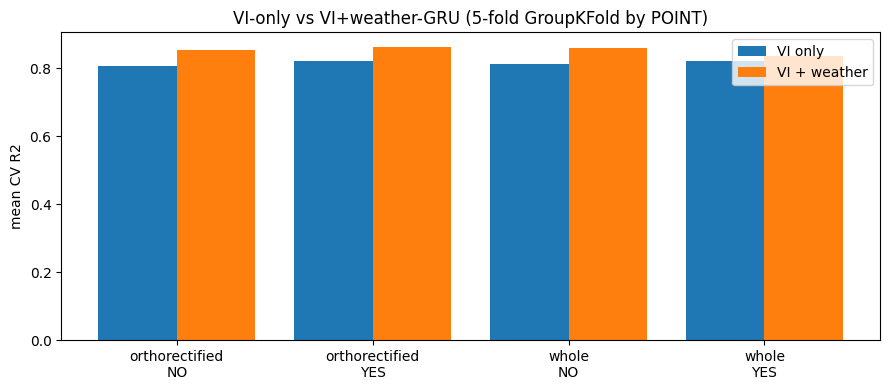

In [8]:
s = summary.copy()
s["combo"] = s["METHOD"] + "\n" + s["SOIL"]
x = np.arange(len(s))
fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(x - 0.2, s["VI_only_R2"], width=0.4, label="VI only")
ax.bar(x + 0.2, s["VI_weather_R2"], width=0.4, label="VI + weather")
ax.set_xticks(x)
ax.set_xticklabels(s["combo"])
ax.set_ylabel("mean CV R2")
ax.set_title("VI-only vs VI+weather-GRU (5-fold GroupKFold by POINT)")
ax.legend()
plt.tight_layout()
plt.show()

## Random Forest baseline (VI features only)

Classical baseline: `RandomForestRegressor` on the same 49 VI features, same 5-fold
`GroupKFold` by `POINT`, no weather. Anchors the neural models against a strong tabular
learner.

In [9]:
rf_results = run_rf_baseline(vi, cfg, vi_cols=vi_cols)
rf_results.groupby(["METHOD", "SOIL"])[["R2", "RMSE", "MAE"]].agg(["mean", "std"])

R2                RMSE                 MAE  \
                         mean       std      mean       std      mean   
METHOD         SOIL                                                     
orthorectified NO    0.874672  0.058123  5.161799  1.088821  2.394960   
               YES   0.879283  0.047337  5.084839  0.961498  2.415103   
whole          NO    0.825656  0.052438  6.147710  0.912633  2.954694   
               YES   0.866990  0.032285  5.388116  0.629345  2.375109   

                               
                          std  
METHOD         SOIL            
orthorectified NO    0.465031  
               YES   0.422531  
whole          NO    0.556962  
               YES   0.397781

In [10]:
rf_r2 = rf_results.groupby(["METHOD", "SOIL"])["R2"].mean().rename("RF_VI_only_R2")
compare = summary.merge(rf_r2, on=["METHOD", "SOIL"])
compare = compare[["METHOD", "SOIL", "RF_VI_only_R2", "VI_only_R2", "VI_weather_R2", "delta_R2"]]
compare

,METHOD,SOIL,RF_VI_only_R2,VI_only_R2,VI_weather_R2,delta_R2
0,orthorectified,NO,0.874672,0.805579,0.853615,0.048035
1,orthorectified,YES,0.879283,0.822329,0.862351,0.040021
2,whole,NO,0.825656,0.812433,0.858400,0.045967
3,whole,YES,0.866990,0.820540,0.837235,0.016695


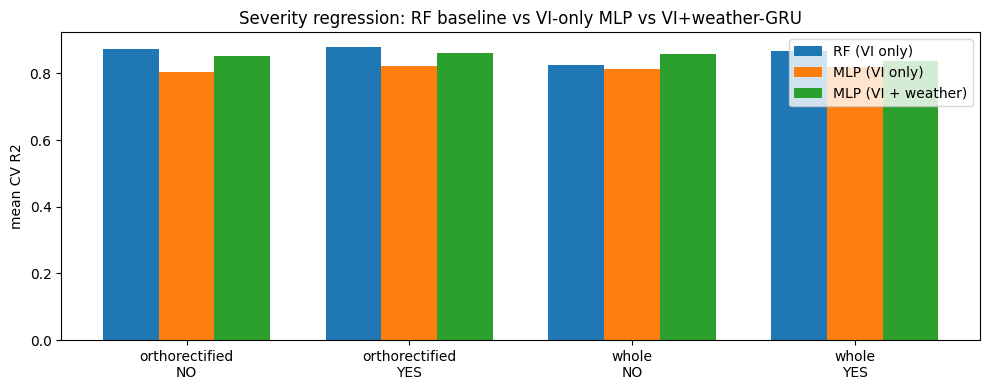

In [11]:
c = compare.copy()
c["combo"] = c["METHOD"] + "\n" + c["SOIL"]
x = np.arange(len(c))
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(x - 0.25, c["RF_VI_only_R2"], width=0.25, label="RF (VI only)")
ax.bar(x, c["VI_only_R2"], width=0.25, label="MLP (VI only)")
ax.bar(x + 0.25, c["VI_weather_R2"], width=0.25, label="MLP (VI + weather)")
ax.set_xticks(x)
ax.set_xticklabels(c["combo"])
ax.set_ylabel("mean CV R2")
ax.set_title("Severity regression: RF baseline vs VI-only MLP vs VI+weather-GRU")
ax.legend()
plt.tight_layout()
plt.show()

## MLP training diagnostics (why does the MLP trail RF?)

Per-epoch **train / val loss** (MSE in log1p-severity space) and **val R2**, averaged over the
5 folds, for the VI-only MLP; the RF val R2 is drawn as a reference line. Reading the curves:

- train loss keeps falling while val loss rises -> **overfitting** (early stopping / more regularization),
- both losses plateau high / val R2 still climbing at the last epoch -> **underfitting / undertrained**.

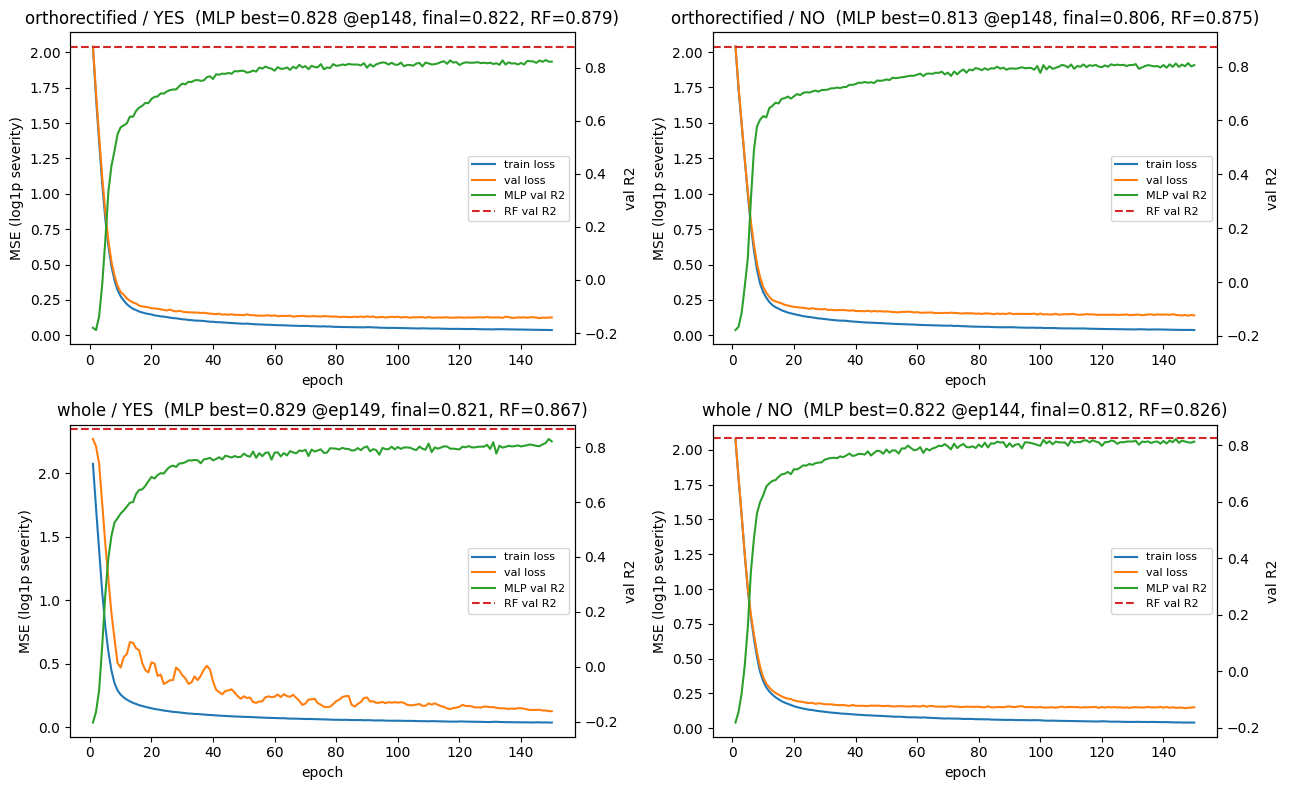

In [12]:
def train_history(df_combo, daily, cfg, vi_cols):
    device = cfg.device
    wscaler = StandardScaler().fit(daily.to_numpy())
    daily_s = pd.DataFrame(wscaler.transform(daily.to_numpy()), index=daily.index, columns=daily.columns)
    dates = pd.to_datetime(df_combo["DATE"], format="%m%d%Y").dt.normalize()
    seqs = build_sequences(daily_s, dates.unique())
    bank_np, lengths_np = seqs.padded_bank()
    bank = torch.tensor(bank_np, device=device)
    lengths = torch.tensor(lengths_np)
    didx = np.array([seqs.date_to_idx[d] for d in dates], dtype=np.int64)

    X = df_combo[vi_cols].to_numpy(np.float32)
    y = df_combo["SEVERITY"].to_numpy(np.float32)
    groups = df_combo["POINT"].to_numpy()

    hist = []
    gkf = GroupKFold(n_splits=cfg.n_splits)
    for fold, (tr, te) in enumerate(gkf.split(X, y, groups)):
        set_seed(cfg.seed + fold)
        vi_scaler = StandardScaler().fit(X[tr])
        X_tr = torch.tensor(vi_scaler.transform(X[tr]), device=device)
        X_te = torch.tensor(vi_scaler.transform(X[te]), device=device)
        d_tr = torch.tensor(didx[tr], device=device)
        d_te = torch.tensor(didx[te], device=device)
        y_te_raw = y[te]
        cap = np.log1p(y[tr].max())
        y_tr = torch.tensor(np.log1p(y[tr]) if cfg.log_target else y[tr], device=device)
        y_te = torch.tensor(np.log1p(y[te]) if cfg.log_target else y[te], device=device)

        model = FusionRegressor(X.shape[1], bank.shape[2], cfg).to(device)
        opt = torch.optim.Adam(model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)
        loss_fn = nn.MSELoss()
        n = len(tr)
        order = np.arange(n)
        for ep in range(cfg.epochs):
            model.train()
            np.random.shuffle(order)
            for s in range(0, n, cfg.batch_size):
                b = order[s : s + cfg.batch_size]
                opt.zero_grad()
                loss_fn(model(X_tr[b], d_tr[b], bank, lengths), y_tr[b]).backward()
                nn.utils.clip_grad_norm_(model.parameters(), cfg.max_grad_norm)
                opt.step()
            model.eval()
            with torch.no_grad():
                tl = loss_fn(model(X_tr, d_tr, bank, lengths), y_tr).item()
                pte = model(X_te, d_te, bank, lengths)
                vl = loss_fn(pte, y_te).item()
                p = pte.cpu().numpy()
            if cfg.log_target:
                p = np.expm1(np.clip(p, None, cap))
            hist.append({"FOLD": fold, "EPOCH": ep + 1, "train_loss": tl, "val_loss": vl, "val_R2": r2_score(y_te_raw, p)})
    return pd.DataFrame(hist)


mlp_cfg = replace(cfg, use_weather=False)
rf_mean = rf_results.groupby(["METHOD", "SOIL"])["R2"].mean()

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
for ax, (method, soil) in zip(axes.flat, DEFAULT_COMBOS):
    sub = vi[(vi["METHOD"] == method) & (vi["SOIL"] == soil)].reset_index(drop=True)
    m = train_history(sub, daily, mlp_cfg, vi_cols).groupby("EPOCH")[["train_loss", "val_loss", "val_R2"]].mean()
    ax.plot(m.index, m["train_loss"], color="tab:blue", label="train loss")
    ax.plot(m.index, m["val_loss"], color="tab:orange", label="val loss")
    ax.set_xlabel("epoch")
    ax.set_ylabel("MSE (log1p severity)")
    ax2 = ax.twinx()
    ax2.plot(m.index, m["val_R2"], color="tab:green", label="MLP val R2")
    ax2.axhline(rf_mean[(method, soil)], color="tab:red", ls="--", label="RF val R2")
    ax2.set_ylabel("val R2")
    ax.set_title(f"{method} / {soil}  (MLP best={m['val_R2'].max():.3f} @ep{m['val_R2'].idxmax()}, final={m['val_R2'].iloc[-1]:.3f}, RF={rf_mean[(method, soil)]:.3f})")
    lines = ax.get_lines() + ax2.get_lines()
    ax.legend(lines, [l.get_label() for l in lines], loc="center right", fontsize=8)
plt.tight_layout()
plt.show()

# Part C — Forecasting / early warning (honest temporal evaluation)

The nowcasting results above use `GroupKFold` by POINT, which shows **every flight date in
both train and test**. Since weather is field-level (shared by all plots on a date) and
severity rises monotonically, that lets the model peek at each date's epidemic stage — the
~+0.04 "weather lift" is partly **temporal leakage**.

Here we reframe to the real agronomic task: **given a plot's last UAV VI snapshot at an
anchor date and weather up to a future target date, forecast that plot's future SEVERITY.**

- **Sample** = ordered date pair `(t_i -> t_j)` per plot: `VI_anchor(49)` + `horizon` (days)
  -> `SEVERITY(t_j)`. C(11,2)x135 = 7425 pairs/combo.
- **Weather variants**: `none` (VI+horizon only); `to_target` (weather through t_j, i.e. a
  weather *forecast* over the horizon); `to_anchor` (strict, no future weather).
- **Evaluation = forward-chaining by target date**: train on pairs with `target_date < D_k`,
  test on `target_date == D_k` (expanding window). No test date is ever seen in training.
- **Headline metric = skill vs persistence** `= 1 - RMSE_model / RMSE_persistence`, because
  absolute R2 is dominated by the late-season severity explosion (all models, and
  persistence itself, score R2 << 0 there).

In [13]:
from math import comb

CONDUCIVE_RH, CONDUCIVE_TMIN, CONDUCIVE_TMAX = 0.75, 16.0, 23.0


def make_forecast_pairs(df_combo):
    d = df_combo.copy()
    d["DATE"] = pd.to_datetime(d["DATE"], format="%m%d%Y").dt.normalize()
    d = d.sort_values(["POINT", "DATE"]).reset_index(drop=True)
    cols = vi_feature_cols(d)
    va, ad, td, hz, ys, pid, sa = [], [], [], [], [], [], []
    for p, g in d.groupby("POINT"):
        g = g.reset_index(drop=True)
        dates = g["DATE"].tolist()
        X = g[cols].to_numpy(np.float32)
        sev = g["SEVERITY"].to_numpy(np.float32)
        for i in range(len(g)):
            for j in range(i + 1, len(g)):
                va.append(X[i]); ad.append(dates[i]); td.append(dates[j])
                hz.append((dates[j] - dates[i]).days); ys.append(sev[j]); pid.append(p); sa.append(sev[i])
    return dict(VI_anchor=np.stack(va), anchor_date=np.array(ad), target_date=np.array(td),
                horizon_days=np.array(hz, np.float32), y=np.array(ys, np.float32),
                plot_id=np.array(pid), sev_anchor=np.array(sa, np.float32))


def horizon_weather_features(daily, t_i, t_j, upto="target"):
    end = t_j if upto == "target" else t_i
    w = daily.loc[t_i:end]
    cond = ((w["rh_mean"] > CONDUCIVE_RH) & w["air_temp_mean"].between(CONDUCIVE_TMIN, CONDUCIVE_TMAX)).sum()
    return {"gdd_sum": w["gdd"].sum(), "precip_sum_h": w["precip_sum"].sum(),
            "leaf_wet_hours_sum": w["leaf_wet_hours"].sum(), "air_temp_mean_h": w["air_temp_mean"].mean(),
            "air_temp_max_h": w["air_temp_max"].max(), "rh_mean_h": w["rh_mean"].mean(),
            "vpd_mean_h": w["vpd"].mean(), "conducive_days": float(cond), "n_days": float(len(w))}


def _rf_weather_matrix(pairs, daily, upto):
    cache, feats = {}, []
    for a, t in zip(pairs["anchor_date"], pairs["target_date"]):
        k = (a, t)
        if k not in cache:
            cache[k] = horizon_weather_features(daily, pd.Timestamp(a), pd.Timestamp(t), upto)
        feats.append(cache[k])
    return pd.DataFrame(feats).to_numpy(np.float32)


def _tab(pairs, use_sev_anchor):
    base = [pairs["VI_anchor"], pairs["horizon_days"][:, None]]
    if use_sev_anchor:
        base.append(pairs["sev_anchor"][:, None])
    return base


def baseline_forecast(pairs, start_after=5):
    y, tdate, sa = pairs["y"], pairs["target_date"], pairs["sev_anchor"]
    all_d = sorted(pd.unique(tdate))
    rows = []
    for k in range(start_after, len(all_d)):
        Dk = all_d[k]; tr = tdate < Dk; te = tdate == Dk
        yte = y[te]; per = sa[te]; dm = np.full(int(te.sum()), y[tr].mean())
        rows.append({"target_date": Dk, "persist_RMSE": float(np.sqrt(mean_squared_error(yte, per))),
                     "persist_R2": r2_score(yte, per), "mean_RMSE": float(np.sqrt(mean_squared_error(yte, dm))),
                     "mean_R2": r2_score(yte, dm)})
    return pd.DataFrame(rows)


def forward_chaining_rf(pairs, daily, cfg, weather="to_target", start_after=5, use_sev_anchor=False, n_estimators=300):
    base = _tab(pairs, use_sev_anchor)
    if weather != "none":
        base.append(_rf_weather_matrix(pairs, daily, "target" if weather != "to_anchor" else "anchor"))
    X = np.concatenate(base, axis=1).astype(np.float32)
    y, tdate = pairs["y"], pairs["target_date"]; all_d = sorted(pd.unique(tdate))
    rows = []
    for k in range(start_after, len(all_d)):
        Dk = all_d[k]; tr = tdate < Dk; te = tdate == Dk
        if tr.sum() == 0 or te.sum() == 0:
            continue
        m = RandomForestRegressor(n_estimators=n_estimators, random_state=cfg.seed, n_jobs=-1)
        m.fit(X[tr], y[tr]); p = m.predict(X[te]); yte = y[te]
        rows.append({"target_date": Dk, "R2": r2_score(yte, p),
                     "RMSE": float(np.sqrt(mean_squared_error(yte, p))), "MAE": mean_absolute_error(yte, p)})
    return pd.DataFrame(rows)


def forward_chaining_neural(pairs, daily, cfg, weather="to_target", start_after=5, use_sev_anchor=False):
    dev = cfg.device
    ws = StandardScaler().fit(daily.to_numpy())
    ds = pd.DataFrame(ws.transform(daily.to_numpy()), index=daily.index, columns=daily.columns)
    seq_dates = pairs["target_date"] if weather != "to_anchor" else pairs["anchor_date"]
    seqs = build_sequences(ds, pd.unique(seq_dates))
    bnp, lnp = seqs.padded_bank()
    bank = torch.tensor(bnp, device=dev); lengths = torch.tensor(lnp)
    didx = np.array([seqs.date_to_idx[pd.Timestamp(d)] for d in seq_dates])
    Xtab = np.concatenate(_tab(pairs, use_sev_anchor), axis=1).astype(np.float32)
    y, tdate = pairs["y"], pairs["target_date"]; all_d = sorted(pd.unique(tdate))
    cfg2 = replace(cfg, use_weather=(weather != "none"))
    rows, oof = [], []
    for k in range(start_after, len(all_d)):
        Dk = all_d[k]; tr = tdate < Dk; te = tdate == Dk
        if tr.sum() == 0 or te.sum() == 0:
            continue
        set_seed(cfg.seed)
        sc = StandardScaler().fit(Xtab[tr])
        Xtr = torch.tensor(sc.transform(Xtab[tr]), device=dev)
        Xte = torch.tensor(sc.transform(Xtab[te]), device=dev)
        dtr = torch.tensor(didx[tr], device=dev); dte = torch.tensor(didx[te], device=dev)
        cap = np.log1p(y[tr].max())
        ytr = torch.tensor(np.log1p(y[tr]) if cfg.log_target else y[tr], device=dev)
        model = FusionRegressor(Xtab.shape[1], bank.shape[2], cfg2).to(dev)
        opt = torch.optim.Adam(model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)
        lf = nn.MSELoss(); n = int(tr.sum()); order = np.arange(n)
        for _ in range(cfg.epochs):
            model.train(); np.random.shuffle(order)
            for s in range(0, n, cfg.batch_size):
                b = order[s:s + cfg.batch_size]; opt.zero_grad()
                lf(model(Xtr[b], dtr[b], bank, lengths), ytr[b]).backward()
                nn.utils.clip_grad_norm_(model.parameters(), cfg.max_grad_norm); opt.step()
        model.eval()
        with torch.no_grad():
            p = model(Xte, dte, bank, lengths).cpu().numpy()
        if cfg.log_target:
            p = np.expm1(np.clip(p, None, cap))
        yte = y[te]
        rows.append({"target_date": Dk, "R2": r2_score(yte, p),
                     "RMSE": float(np.sqrt(mean_squared_error(yte, p))), "MAE": mean_absolute_error(yte, p)})
        oof.append(pd.DataFrame({"target_date": Dk, "horizon": pairs["horizon_days"][te], "y": yte, "pred": p}))
    return pd.DataFrame(rows), pd.concat(oof, ignore_index=True)


def run_forecast_experiment(vi_df, daily, cfg, combos=DEFAULT_COMBOS, weathers=("none", "to_target")):
    per_date, oof_all = [], []
    for method, soil in combos:
        sub = vi_df[(vi_df["METHOD"] == method) & (vi_df["SOIL"] == soil)].reset_index(drop=True)
        pairs = make_forecast_pairs(sub)
        base = baseline_forecast(pairs)
        for _, r in base.iterrows():
            per_date.append({"METHOD": method, "SOIL": soil, "MODEL": "Persistence", "WEATHER": "-",
                             "target_date": r.target_date, "RMSE": r.persist_RMSE, "R2": r.persist_R2})
            per_date.append({"METHOD": method, "SOIL": soil, "MODEL": "DateMean", "WEATHER": "-",
                             "target_date": r.target_date, "RMSE": r.mean_RMSE, "R2": r.mean_R2})
        for w in weathers:
            rf = forward_chaining_rf(pairs, daily, cfg, weather=w)
            for _, r in rf.iterrows():
                per_date.append({"METHOD": method, "SOIL": soil, "MODEL": "RF", "WEATHER": w,
                                 "target_date": r.target_date, "RMSE": r.RMSE, "R2": r.R2})
            nn_r, oof = forward_chaining_neural(pairs, daily, cfg, weather=w)
            oof["METHOD"], oof["SOIL"], oof["WEATHER"] = method, soil, w
            oof_all.append(oof)
            for _, r in nn_r.iterrows():
                per_date.append({"METHOD": method, "SOIL": soil, "MODEL": "NN", "WEATHER": w,
                                 "target_date": r.target_date, "RMSE": r.RMSE, "R2": r.R2})
    per_date = pd.DataFrame(per_date)
    persist = (per_date[per_date.MODEL == "Persistence"][["METHOD", "SOIL", "target_date", "RMSE"]]
               .rename(columns={"RMSE": "persist_RMSE"}))
    per_date = per_date.merge(persist, on=["METHOD", "SOIL", "target_date"])
    per_date["skill"] = 1 - per_date["RMSE"] / per_date["persist_RMSE"]
    return per_date, pd.concat(oof_all, ignore_index=True)

In [14]:
fc_cfg = replace(cfg, epochs=100, log_target=False)

fc_per_date, fc_oof = run_forecast_experiment(vi, daily, fc_cfg)

# headline: mean skill vs persistence and mean RMSE, averaged over test dates and combos
fc_summary = (fc_per_date.groupby(["MODEL", "WEATHER"])[["skill", "RMSE", "R2"]]
              .mean().reset_index().sort_values("skill", ascending=False))
fc_summary

,MODEL,WEATHER,skill,RMSE,R2
1,NN,none,0.306442,9.355211,-0.481936
4,RF,none,0.227930,11.231474,-0.915664
5,RF,to_target,0.182178,12.906547,-1.288264
0,DateMean,-,0.044105,15.410748,-2.161719
2,NN,to_target,0.040272,15.515718,-2.187789
3,Persistence,-,0.000000,16.246174,-2.487830


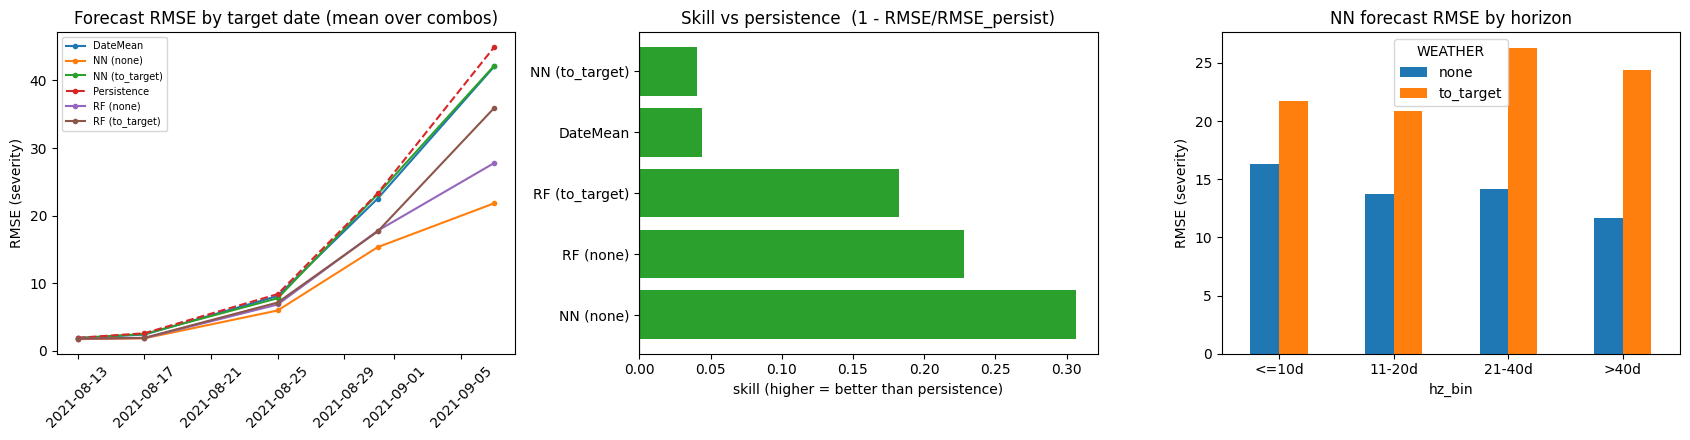

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))

# (1) RMSE vs target date (mean over combos): models vs persistence
piv = fc_per_date.assign(key=fc_per_date.MODEL + np.where(fc_per_date.WEATHER == "-", "", " (" + fc_per_date.WEATHER + ")"))
rmse_by_date = piv.groupby(["key", "target_date"])["RMSE"].mean().unstack("key")
for col in rmse_by_date.columns:
    style = "--" if col == "Persistence" else "-"
    axes[0].plot(rmse_by_date.index, rmse_by_date[col], style, marker="o", ms=3, label=col)
axes[0].set_title("Forecast RMSE by target date (mean over combos)")
axes[0].set_ylabel("RMSE (severity)")
axes[0].tick_params(axis="x", rotation=45)
axes[0].legend(fontsize=7)

# (2) skill vs persistence by model (mean over dates+combos)
sk = fc_summary[~fc_summary.MODEL.isin(["Persistence"])].copy()
sk["key"] = sk.MODEL + np.where(sk.WEATHER == "-", "", " (" + sk.WEATHER + ")")
axes[1].barh(sk["key"], sk["skill"], color=["tab:green" if v > 0 else "tab:red" for v in sk["skill"]])
axes[1].axvline(0, color="k", lw=0.8)
axes[1].set_title("Skill vs persistence  (1 - RMSE/RMSE_persist)")
axes[1].set_xlabel("skill (higher = better than persistence)")

# (3) per-horizon RMSE: does weather help at longer lead times?
fc_oof["hz_bin"] = pd.cut(fc_oof["horizon"], [0, 10, 20, 40, 80], labels=["<=10d", "11-20d", "21-40d", ">40d"])
hz = (fc_oof.groupby(["WEATHER", "hz_bin"], observed=True)
      .apply(lambda x: np.sqrt(mean_squared_error(x.y, x.pred))).unstack("WEATHER"))
hz.plot(kind="bar", ax=axes[2])
axes[2].set_title("NN forecast RMSE by horizon")
axes[2].set_ylabel("RMSE (severity)")
axes[2].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

In [16]:
# Realistic add-on: at spray-decision time the agronomist knows the plot's CURRENT severity.
# Does adding sev_anchor (last-known severity) help the RF forecaster? (skill vs persistence)
rows = []
for method, soil in DEFAULT_COMBOS:
    sub = vi[(vi["METHOD"] == method) & (vi["SOIL"] == soil)].reset_index(drop=True)
    pairs = make_forecast_pairs(sub)
    base = baseline_forecast(pairs).set_index("target_date")
    for use_sa in (False, True):
        rf = forward_chaining_rf(pairs, daily, fc_cfg, weather="none", use_sev_anchor=use_sa).set_index("target_date")
        skill = (1 - rf["RMSE"] / base["persist_RMSE"]).mean()
        rows.append({"METHOD": method, "SOIL": soil, "sev_anchor": use_sa, "mean_skill": skill, "mean_RMSE": rf["RMSE"].mean()})
sev_anchor_effect = pd.DataFrame(rows).pivot_table(index=["METHOD", "SOIL"], columns="sev_anchor", values=["mean_skill", "mean_RMSE"])
sev_anchor_effect

mean_RMSE            mean_skill          
sev_anchor               False      True       False     True 
METHOD         SOIL                                           
orthorectified NO    11.072598  10.720441   0.232316  0.252099
               YES   11.140874  10.776655   0.232556  0.256574
whole          NO    11.299015  10.808155   0.225950  0.248696
               YES   11.413411  10.842186   0.220899  0.250650

## Part C findings

- **Under honest forward-chaining, absolute-severity R2 is negative for every model** —
  including persistence — because training sees only earlier, low-severity dates and must
  extrapolate the late-season epidemic explosion. With a single site-year this is a hard data
  limit, so we judge models by **skill vs persistence** (RMSE reduction), not R2.
- **VI + horizon forecasts do beat persistence** (positive skill at every test date): the last
  UAV snapshot carries real lead-time information about a plot's trajectory.
- **Field-level weather does NOT add forecasting skill — it slightly hurts** (both the RF with
  engineered horizon-weather features and the GRU branch). This confirms the leakage thesis:
  the ~+0.04 "lift" under GroupKFold was largely the model reading each date's epidemic stage.
  One station × one season provides no *cross-plot* signal (weather is identical across plots)
  and its single across-season trajectory doesn't generalize across the temporal split.
- **Deployment implication:** the operational path (per-plot risk map for spray timing) works
  from **VI + last-known severity**, refreshed each flight; weather-driven early warning needs
  **multiple site-years** and public/gridded weather before it earns its place. This is the
  concrete "how to improve" answer given the current single-season constraint.